# Gold — Volume de Procedimentos: Brasil x demais países ISAPS

Constrói a camada **Gold** a partir da Silver do ISAPS (`procedures_by_country`), com o volume de procedimentos estéticos por país e ano (2018-2024), para comparar o Brasil com os demais países da pesquisa — tanto o **volume total** quanto a quebra **por procedimento específico** (Rhinoplasty, Breast Augmentation, Botulinum Toxin etc.).

**Limitação já registrada na EDA e mantida aqui, de propósito:** dá para comparar volume bruto entre países, mas não per capita — só temos população para o Brasil (IBGE), não para os outros ~37 países. Um ranking por volume absoluto tende a favorecer países populosos (EUA, Brasil, China); não é um indicador de "taxa de procedimentos por habitante".

## 1. Imports e configuração

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from minio import Minio
from sqlalchemy import create_engine, text

In [2]:
load_dotenv(Path.cwd().parent / ".env")

MINIO_ENDPOINT = os.getenv("MINIO_ENDPOINT", "localhost:9000")
MINIO_ACCESS_KEY = os.getenv("MINIO_ACCESS_KEY")
MINIO_SECRET_KEY = os.getenv("MINIO_SECRET_KEY")

BUCKET_SILVER = os.getenv("BUCKET_SILVER", "silver")
SILVER_PREFIX = "procedures_by_country/"

BUCKET_GOLD = os.getenv("BUCKET_GOLD", "gold")
GOLD_PREFIX = "isaps_volume/"

GOLD_DIR = Path.cwd().parent / "dados_processados" / "gold" / "isaps_volume"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

client = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS_KEY, secret_key=MINIO_SECRET_KEY, secure=False)
if not client.bucket_exists(BUCKET_GOLD):
    client.make_bucket(BUCKET_GOLD)
    print(f"Bucket '{BUCKET_GOLD}' criado.")

PG_DATA_USER = os.getenv("PG_DATA_USER", "postgres")
PG_DATA_PASSWORD = os.getenv("PG_DATA_PASSWORD", "postgres")
PG_DATA_DB = os.getenv("PG_DATA_DB", "projeto-ai")
PG_DATA_HOST = os.getenv("PG_DATA_HOST", "localhost")
PG_DATA_PORT = os.getenv("PG_DATA_PORT", "5434")
PG_SCHEMA = "gold"

engine = create_engine(f"postgresql+psycopg2://{PG_DATA_USER}:{PG_DATA_PASSWORD}@{PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB}")
with engine.begin() as conn:
    conn.execute(text(f"CREATE SCHEMA IF NOT EXISTS {PG_SCHEMA}"))

print(f"MinIO: {MINIO_ENDPOINT} | bucket silver: {BUCKET_SILVER} | bucket gold: {BUCKET_GOLD}")
print(f"Postgres: {PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB} | schema: {PG_SCHEMA}")
print(f"Saida parquet local: {GOLD_DIR}")

MinIO: localhost:9000 | bucket silver: silver | bucket gold: gold
Postgres: localhost:5434/projeto-ai | schema: gold
Saida parquet local: C:\Projeto_AI\dados_processados\gold\isaps_volume


## 2. Carregamento da Silver ISAPS

In [3]:
objetos = list(client.list_objects(BUCKET_SILVER, prefix=SILVER_PREFIX, recursive=True))
dfs = []
for obj in objetos:
    data = client.get_object(BUCKET_SILVER, obj.object_name).read()
    dfs.append(pd.read_parquet(pd.io.common.BytesIO(data)))

isaps = pd.concat(dfs, ignore_index=True)
print(f"Shape: {isaps.shape} | anos: {sorted(isaps['ano_referencia'].unique())} | paises: {isaps['pais'].nunique()}")

Shape: (5382, 9) | anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)] | paises: 38


## 3. Extração do volume total por país/ano — cuidado com contagem em dobro

A tabela `procedures_by_country` traz, na mesma coluna `quantidade`, tanto procedimentos individuais (ex.: `Rhinoplasty`) quanto subtotais de categoria (ex.: `Total Face & Head Procedures`) e o grande total (`Total Procedures`). **Somar `quantidade` direto por país/ano contaria cada procedimento várias vezes** — uma vez como linha individual, de novo dentro do subtotal da sua categoria, e mais uma vez dentro do grande total.

A forma correta de chegar no volume total por país/ano é somar exatamente **dois** valores já agregados pelo próprio ISAPS: o total cirúrgico e o total não-cirúrgico — sem tocar nas linhas individuais nem nos subtotais de categoria. O total cirúrgico usa sempre o mesmo rótulo (`Total Surgical Procedures`); o não-cirúrgico varia de grafia entre anos (`Total Non-Surgical`, `Total Non-Surgical Procedures`, `Total Nonsurgical Procedures` — mesmo tipo de inconsistência de grafia já visto para país na Silver), por isso entram como um conjunto de rótulos equivalentes, não um só. (Não uso o "grande total" pronto, do tipo `Total Procedures`/`TOTAL PROCEDURES`/`Total SURGICAL & NON-SURGICAL Procedures`, porque ele *também* varia de grafia entre anos e apurar duas somas já confiáveis é mais simples e mais fácil de auditar do que reconciliar três grafias diferentes de uma linha só.)

In [4]:
ROTULO_TOTAL_CIRURGICO = {"Total Surgical Procedures"}
ROTULOS_TOTAL_NAO_CIRURGICO = {"Total Non-Surgical", "Total Non-Surgical Procedures", "Total Nonsurgical Procedures"}

total_cirurgico = isaps[
    (isaps["tipo_procedimento"] == "CIRURGICO") & (isaps["procedimento"].isin(ROTULO_TOTAL_CIRURGICO))
][["pais", "ano_referencia", "quantidade"]].rename(columns={"quantidade": "quantidade_cirurgico"})

total_nao_cirurgico = isaps[
    (isaps["tipo_procedimento"] == "NAO-CIRURGICO") & (isaps["procedimento"].isin(ROTULOS_TOTAL_NAO_CIRURGICO))
][["pais", "ano_referencia", "quantidade"]].rename(columns={"quantidade": "quantidade_nao_cirurgico"})

**Confirma cobertura completa antes de seguir**: cada combinação `pais`/`ano_referencia` da Silver precisa ter exatamente uma linha de total cirúrgico e uma de total não-cirúrgico — nem menos (perderia país/ano na Gold) nem mais (indicaria duplicidade).

In [5]:
pares_esperados = isaps[["pais", "ano_referencia"]].drop_duplicates()

for nome, total_df in [("cirurgico", total_cirurgico), ("nao_cirurgico", total_nao_cirurgico)]:
    contagem = total_df.groupby(["pais", "ano_referencia"]).size()
    fora_do_esperado = (contagem != 1).sum()
    faltando = len(pares_esperados) - len(total_df)
    print(f"{nome}: {len(total_df)} linhas | pais/ano com contagem != 1: {fora_do_esperado} | faltando: {faltando}")

assert len(total_cirurgico) == len(pares_esperados)
assert len(total_nao_cirurgico) == len(pares_esperados)
print("Cobertura completa confirmada.")

cirurgico: 125 linhas | pais/ano com contagem != 1: 0 | faltando: 0
nao_cirurgico: 125 linhas | pais/ano com contagem != 1: 0 | faltando: 0
Cobertura completa confirmada.


## 4. Tabela fato — `volume_procedimentos_isaps_pais_ano` (agregado)

Junta os dois totais por `pais`/`ano_referencia`, soma para o volume total, e adiciona o ranking do país naquele ano (1 = maior volume) — dá pra ler direto em que posição o Brasil está a cada ano, sem recalcular.

In [6]:
volume = pd.merge(total_cirurgico, total_nao_cirurgico, on=["pais", "ano_referencia"], how="inner")
volume["quantidade_total"] = volume["quantidade_cirurgico"] + volume["quantidade_nao_cirurgico"]
volume["ranking_no_ano"] = volume.groupby("ano_referencia")["quantidade_total"].rank(ascending=False, method="min").astype(int)
volume = volume.rename(columns={"ano_referencia": "ano"}).sort_values(["ano", "ranking_no_ano"]).reset_index(drop=True)

print(f"Shape: {volume.shape}")
volume[volume["pais"] == "BRAZIL"]

Shape: (125, 6)


,pais,ano,quantidade_cirurgico,quantidade_nao_cirurgico,quantidade_total,ranking_no_ano
1,BRAZIL,2018,1498327.0,769078.0,2267405.0,2
11,BRAZIL,2019,1493673.0,1072002.0,2565675.0,2
27,BRAZIL,2020,1306962.0,622396.0,1929358.0,2
41,BRAZIL,2021,1634220.0,1089420.0,2723640.0,2
55,BRAZIL,2022,2049257.0,971294.0,3020551.0,2
71,BRAZIL,2023,2185038.0,1196513.0,3381551.0,2
94,BRAZIL,2024,2354513.0,769245.0,3123758.0,2


## 5. Tabela fato — `volume_procedimentos_isaps_pais_ano_procedimento` (por procedimento específico)

Mesma fonte, granularidade diferente: em vez do total cirúrgico/não-cirúrgico, mantém cada procedimento individual (`Rhinoplasty`, `Breast Augmentation`, `Botulinum Toxin` etc.) como sua própria linha — o oposto da tabela anterior, que soma justamente para *não* olhar o procedimento específico.

A mesma regra de "cuidado com contagem em dobro" da seção 3 se aplica ao contrário aqui: **as linhas `Total ...`/`TOTAL ...` (agregados) são excluídas**, porque misturar procedimento individual com subtotal de categoria na mesma coluna quebraria qualquer comparação por procedimento — um subtotal apareceria como se fosse "mais um procedimento", inflando artificialmente o que for somado por país.

In [7]:
individuais = isaps[~isaps["procedimento"].str.upper().str.startswith("TOTAL")].copy()

volume_procedimento = individuais[
    ["pais", "ano_referencia", "tipo_procedimento", "categoria_pt", "procedimento_pt", "quantidade"]
].rename(columns={"ano_referencia": "ano"})

volume_procedimento["ranking_no_ano_procedimento"] = (
    volume_procedimento.groupby(["ano", "procedimento_pt"])["quantidade"].rank(ascending=False, method="min").astype(int)
)
volume_procedimento = volume_procedimento.sort_values(["ano", "procedimento_pt", "ranking_no_ano_procedimento"]).reset_index(drop=True)

print(f"Shape: {volume_procedimento.shape} | procedimentos distintos: {volume_procedimento['procedimento_pt'].nunique()}")
volume_procedimento[(volume_procedimento["pais"] == "BRAZIL") & (volume_procedimento["ano"] == 2024)].sort_values("ranking_no_ano_procedimento").head(10)

Shape: (4257, 7) | procedimentos distintos: 49


,pais,ano,tipo_procedimento,categoria_pt,procedimento_pt,quantidade,ranking_no_ano_procedimento
2977,BRAZIL,2024,CIRURGICO,Corpo e Extremidades,Abdominoplastia,192961.0,1
3041,BRAZIL,2024,CIRURGICO,Corpo e Extremidades,Aumento de Glúteo,168272.0,1
3073,BRAZIL,2024,CIRURGICO,Mama,Aumento de Mama,232593.0,1
3137,BRAZIL,2024,CIRURGICO,Face e Cabeça,Blefaroplastia,231293.0,1
3201,BRAZIL,2024,CIRURGICO,Face e Cabeça,Contorno Ósseo Facial,20141.0,1
3329,BRAZIL,2024,CIRURGICO,Face e Cabeça,Enxerto de Gordura na Face,112398.0,1
3457,BRAZIL,2024,CIRURGICO,Corpo e Extremidades,Lifting Corporal Inferior,17542.0,1
3489,BRAZIL,2024,CIRURGICO,Corpo e Extremidades,Lifting Corporal Superior,11045.0,1
3745,BRAZIL,2024,CIRURGICO,Corpo e Extremidades,Ninfoplastia,29237.0,1
3777,BRAZIL,2024,CIRURGICO,Face e Cabeça,Otoplastia,39632.0,1


## 6. Gravação em Parquet (Gold) e no Postgres

As duas tabelas (agregada e por procedimento), local (`dados_processados/gold/isaps_volume/`), MinIO (bucket `gold`) e Postgres (schema `gold`, recriadas a cada execução).

In [8]:
tabelas_gold = {
    "volume_procedimentos_isaps_pais_ano": volume,
    "volume_procedimentos_isaps_pais_ano_procedimento": volume_procedimento,
}

arquivos_gerados = {}
for nome, df in tabelas_gold.items():
    out_path = GOLD_DIR / f"{nome}.parquet"
    df.to_parquet(out_path, engine="pyarrow", index=False)
    arquivos_gerados[nome] = out_path

    object_name = f"{GOLD_PREFIX}{nome}.parquet"
    client.fput_object(BUCKET_GOLD, object_name, str(out_path))

    df.to_sql(nome, engine, schema=PG_SCHEMA, if_exists="replace", index=False)

    print(f"Gravado: {out_path} ({len(df)} linhas) -> s3://{BUCKET_GOLD}/{object_name} -> Postgres {PG_SCHEMA}.{nome}")

Gravado: C:\Projeto_AI\dados_processados\gold\isaps_volume\volume_procedimentos_isaps_pais_ano.parquet (125 linhas) -> s3://gold/isaps_volume/volume_procedimentos_isaps_pais_ano.parquet -> Postgres gold.volume_procedimentos_isaps_pais_ano

Gravado: C:\Projeto_AI\dados_processados\gold\isaps_volume\volume_procedimentos_isaps_pais_ano_procedimento.parquet (4257 linhas) -> s3://gold/isaps_volume/volume_procedimentos_isaps_pais_ano_procedimento.parquet -> Postgres gold.volume_procedimentos_isaps_pais_ano_procedimento


## 7. Gráficos

### 7.1 Ranking de países por volume acumulado 2018-2024 (barra horizontal, Brasil destacado)

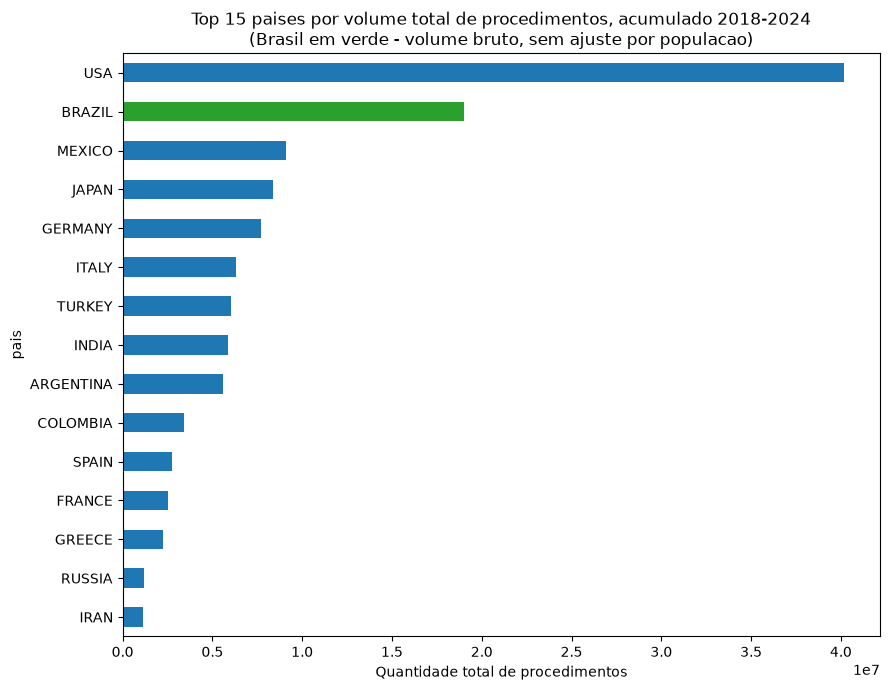

In [9]:
ranking_acumulado = volume.groupby("pais")["quantidade_total"].sum().sort_values(ascending=False)
top15 = ranking_acumulado.head(15).sort_values()
cores = ["tab:green" if pais == "BRAZIL" else "tab:blue" for pais in top15.index]

fig, ax = plt.subplots(figsize=(9, 7))
top15.plot(kind="barh", ax=ax, color=cores)
ax.set_title("Top 15 paises por volume total de procedimentos, acumulado 2018-2024\n(Brasil em verde - volume bruto, sem ajuste por populacao)")
ax.set_xlabel("Quantidade total de procedimentos")
plt.tight_layout()
plt.show()

### 7.2 Evolução do volume: Brasil x principais concorrentes (linhas múltiplas)

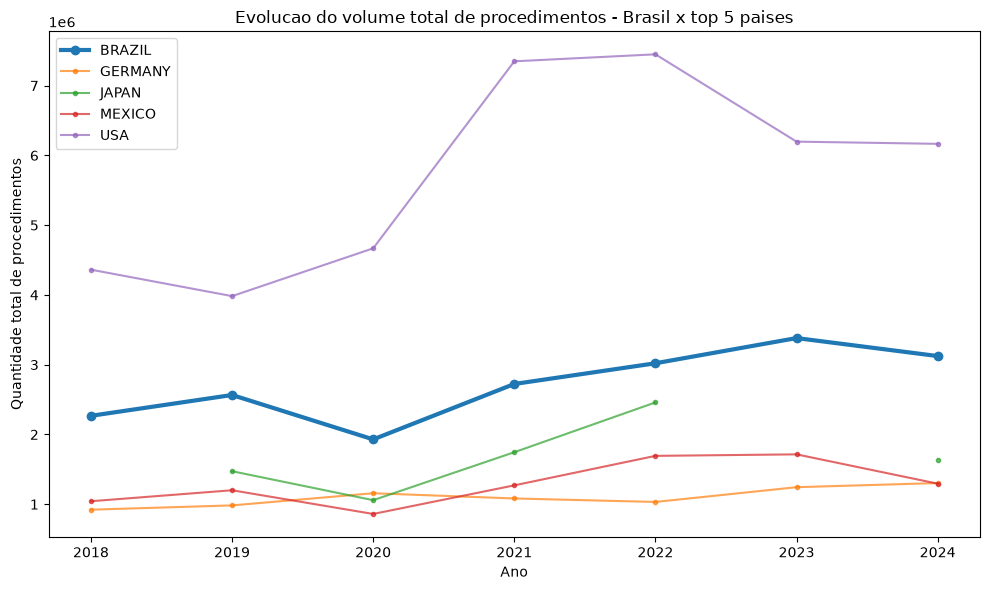

In [10]:
top5_paises = ranking_acumulado.head(5).index.tolist()
if "BRAZIL" not in top5_paises:
    top5_paises.append("BRAZIL")

evolucao = volume[volume["pais"].isin(top5_paises)].pivot(index="ano", columns="pais", values="quantidade_total")

fig, ax = plt.subplots(figsize=(10, 6))
for pais in evolucao.columns:
    estilo = dict(linewidth=3, marker="o") if pais == "BRAZIL" else dict(linewidth=1.5, marker=".", alpha=0.7)
    ax.plot(evolucao.index, evolucao[pais], label=pais, **estilo)
ax.set_title("Evolucao do volume total de procedimentos - Brasil x top 5 paises")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade total de procedimentos")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Posição do Brasil no ranking mundial, por procedimento específico (2024)

Uma barra por procedimento que o Brasil reportou em 2024, mostrando sua posição no ranking daquele procedimento entre os países que também o reportaram (1 = líder mundial naquele procedimento específico). Ordenado do melhor para o pior colocado — mostra de forma direta em quais procedimentos o Brasil lidera globalmente e em quais fica mais atrás, algo que o volume total (gráficos 7.1/7.2) não consegue mostrar sozinho.

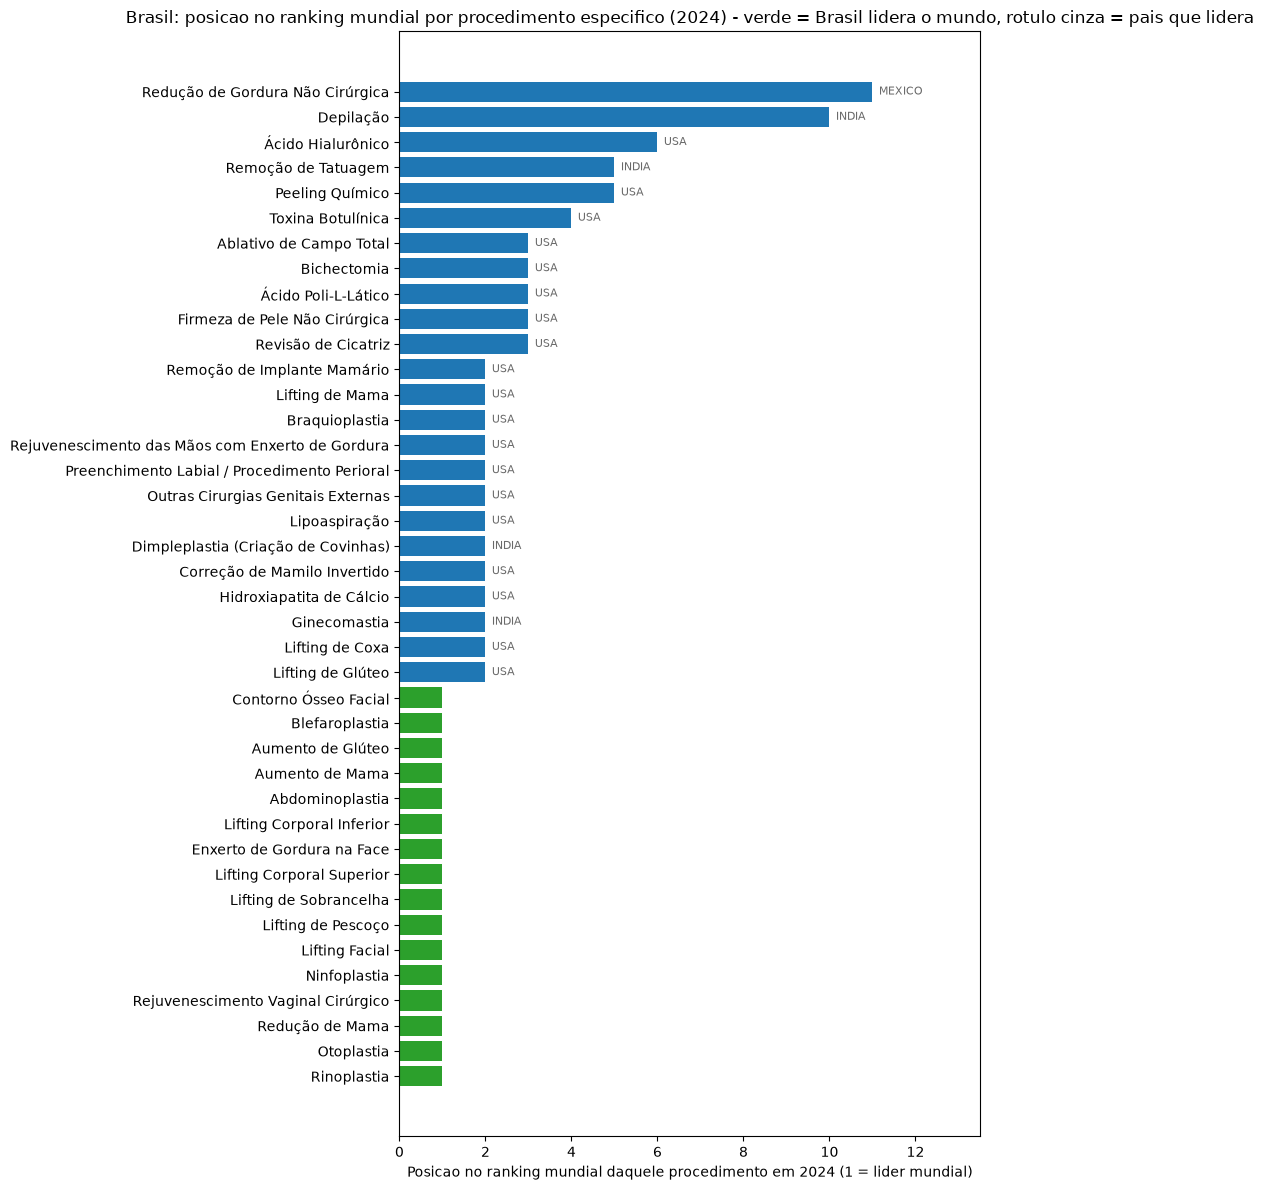

In [11]:
brasil_2024 = volume_procedimento[
    (volume_procedimento["pais"] == "BRAZIL") & (volume_procedimento["ano"] == 2024)
].sort_values("ranking_no_ano_procedimento", ascending=False)

lideres_2024 = volume_procedimento[
    (volume_procedimento["ano"] == 2024) & (volume_procedimento["ranking_no_ano_procedimento"] == 1)
][["procedimento_pt", "pais"]].rename(columns={"pais": "pais_lider"})

brasil_2024 = brasil_2024.merge(lideres_2024, on="procedimento_pt", how="left")

cores_rank = ["tab:green" if r == 1 else "tab:blue" for r in brasil_2024["ranking_no_ano_procedimento"]]

fig, ax = plt.subplots(figsize=(10, 12))
barras = ax.barh(brasil_2024["procedimento_pt"], brasil_2024["ranking_no_ano_procedimento"], color=cores_rank)
ax.invert_yaxis()

for barra, rank, pais_lider in zip(barras, brasil_2024["ranking_no_ano_procedimento"], brasil_2024["pais_lider"]):
    if rank > 1:
        ax.text(barra.get_width() + 0.15, barra.get_y() + barra.get_height() / 2, pais_lider,
                va="center", ha="left", fontsize=8, color="dimgray")

ax.set_xlim(0, brasil_2024["ranking_no_ano_procedimento"].max() + 2.5)
ax.set_xlabel("Posicao no ranking mundial daquele procedimento em 2024 (1 = lider mundial)")
ax.set_title("Brasil: posicao no ranking mundial por procedimento especifico (2024) - verde = Brasil lidera o mundo, rotulo cinza = pais que lidera")
plt.tight_layout()
plt.show()

### 7.4 Brasil x líder mundial (EUA), top 10 procedimentos por volume combinado em 2024 (barra agrupada)

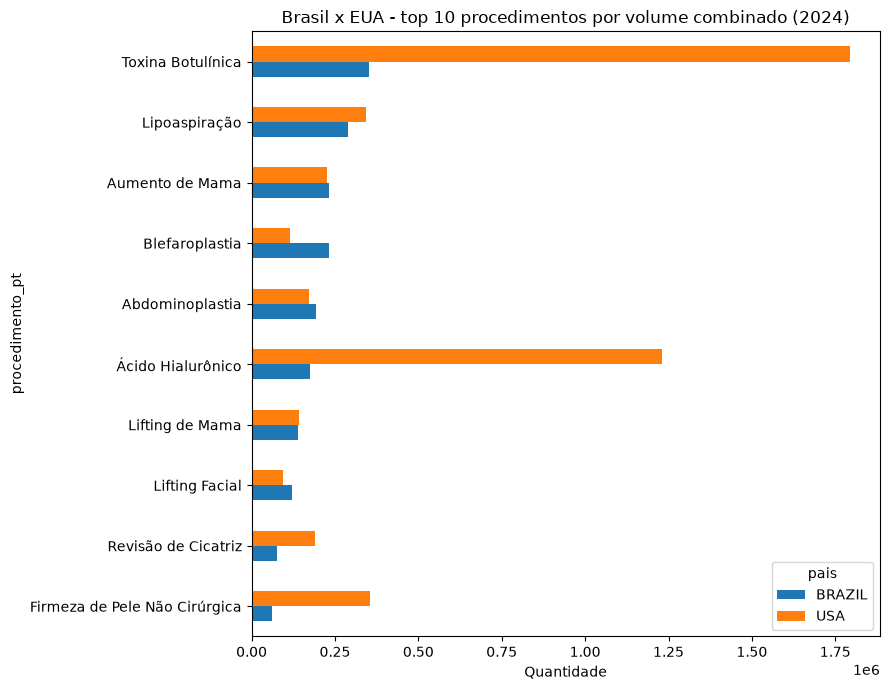

In [12]:
ano_referencia = 2024
paises_comparar = ["BRAZIL", "USA"]

comparativo = volume_procedimento[
    (volume_procedimento["ano"] == ano_referencia) & (volume_procedimento["pais"].isin(paises_comparar))
]
pivot_comparativo = comparativo.pivot_table(index="procedimento_pt", columns="pais", values="quantidade", aggfunc="sum")
pivot_comparativo = pivot_comparativo.dropna()
top10_procedimentos = pivot_comparativo.sum(axis=1).sort_values(ascending=False).head(10).index
pivot_comparativo = pivot_comparativo.loc[top10_procedimentos].sort_values("BRAZIL")

fig, ax = plt.subplots(figsize=(9, 7))
pivot_comparativo.plot(kind="barh", ax=ax)
ax.set_title(f"Brasil x EUA - top 10 procedimentos por volume combinado ({ano_referencia})")
ax.set_xlabel("Quantidade")
plt.tight_layout()
plt.show()

### 7.5 Crescimento de cada procedimento no Brasil, 2018 -> 2024 (barra horizontal)

Variação percentual de `quantidade` entre 2018 e 2024, um procedimento por barra — verde para crescimento, vermelho para queda. Só entram os procedimentos que o Brasil reportou **nos dois anos-ponta** (2018 e 2024): de 48 procedimentos individuais que o Brasil já reportou em algum ano, 27 têm essas duas pontas — os demais foram descartados do gráfico, não arredondados a zero, porque calcular "crescimento" sem um dos dois pontos não é uma taxa de crescimento, é uma invenção.

**Por que a lista de procedimentos parece menor do que os 49 encontrados na seção 5**: uma fração desses 48 é a mesma fragmentação de grafia já documentada como ponto em aberto na Silver ([tratamento_silver_isaps.ipynb](tratamento_silver_isaps.ipynb), seção 6) — por exemplo `Aumento de Glúteo`, `Aumento de Glúteo (Implantes e Enxerto de Gordura)` e `Aumento de Glúteo – Implantes e Enxerto de Gordura` são variações do mesmo procedimento em anos diferentes, tratadas como linhas/identidades separadas. Cada variante isolada tende a aparecer em só 1 ou 2 anos (não em 2018 e 2024 ao mesmo tempo), então esse gráfico já as exclui naturalmente — mas o motivo é essa fragmentação, não que o procedimento tenha sumido.

Procedimentos com dado em 2018 e 2024: 27 de 48 reportados pelo Brasil em algum ano


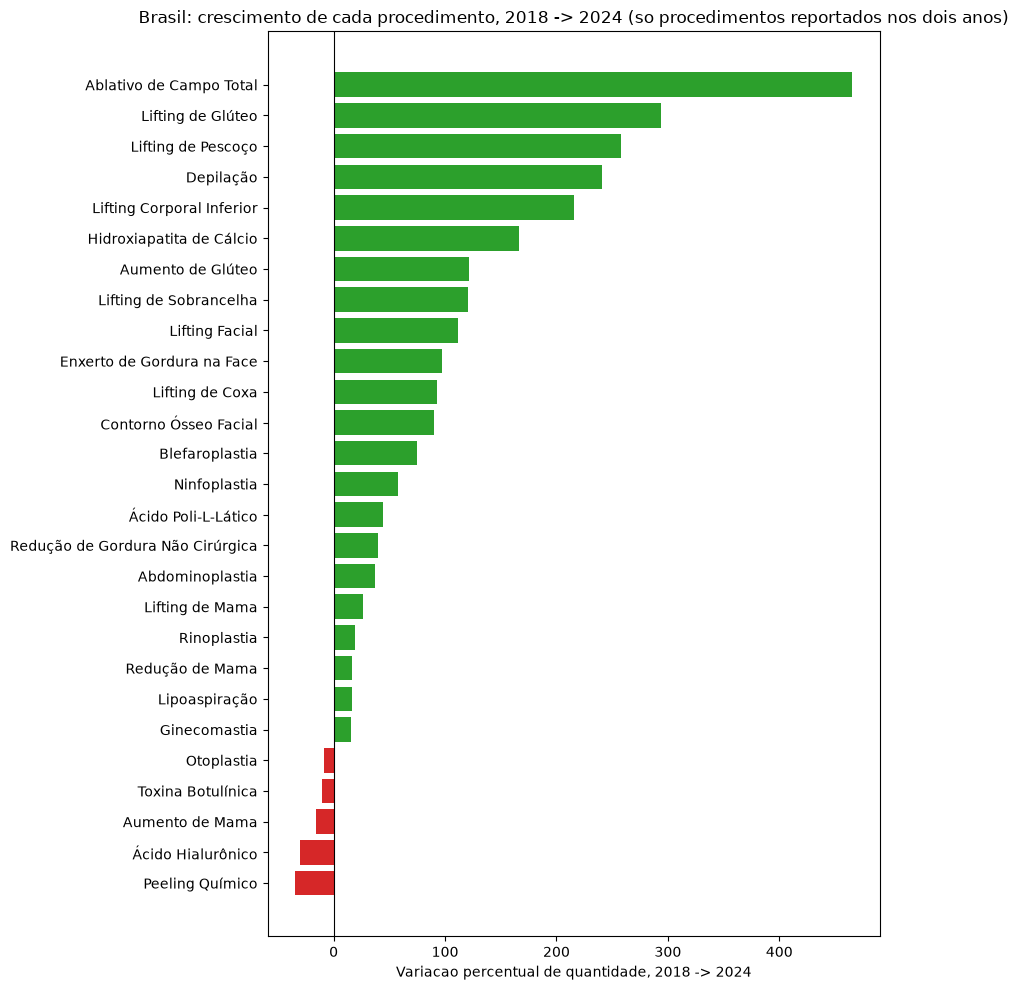

In [13]:
individuais_brasil = individuais[individuais["pais"] == "BRAZIL"]

quantidade_2018 = individuais_brasil[individuais_brasil["ano_referencia"] == 2018].set_index("procedimento_pt")["quantidade"]
quantidade_2024 = individuais_brasil[individuais_brasil["ano_referencia"] == 2024].set_index("procedimento_pt")["quantidade"]

crescimento = pd.DataFrame({"2018": quantidade_2018, "2024": quantidade_2024}).dropna()
crescimento["crescimento_pct"] = ((crescimento["2024"] - crescimento["2018"]) / crescimento["2018"] * 100).round(1)
crescimento = crescimento.sort_values("crescimento_pct")

print(f"Procedimentos com dado em 2018 e 2024: {len(crescimento)} de {individuais_brasil['procedimento_pt'].nunique()} reportados pelo Brasil em algum ano")

cores_crescimento = ["tab:red" if v < 0 else "tab:green" for v in crescimento["crescimento_pct"]]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(crescimento.index, crescimento["crescimento_pct"], color=cores_crescimento)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Variacao percentual de quantidade, 2018 -> 2024")
ax.set_title("Brasil: crescimento de cada procedimento, 2018 -> 2024 (so procedimentos reportados nos dois anos)")
plt.tight_layout()
plt.show()

## 8. Verificação final no Postgres

Confere direto na fonte: lista as duas tabelas recém-gravadas no schema `gold`, suas contagens de linhas, e amostras de cada uma.

In [14]:
with engine.connect() as conn:
    tabelas_pg = conn.execute(text(
        "SELECT table_name FROM information_schema.tables WHERE table_schema = :schema AND table_name = ANY(:tabelas)"
    ), {"schema": PG_SCHEMA, "tabelas": list(tabelas_gold.keys())}).fetchall()

print(f"Tabelas encontradas no Postgres: {[t[0] for t in tabelas_pg]}")

for nome in tabelas_gold:
    with engine.connect() as conn:
        total = conn.execute(text(f'SELECT COUNT(*) FROM {PG_SCHEMA}."{nome}"')).scalar()
    print(f" - {nome}: {total} linhas")

Tabelas encontradas no Postgres: ['volume_procedimentos_isaps_pais_ano', 'volume_procedimentos_isaps_pais_ano_procedimento']
 - volume_procedimentos_isaps_pais_ano: 125 linhas
 - volume_procedimentos_isaps_pais_ano_procedimento: 4257 linhas


In [15]:
with engine.connect() as conn:
    amostra_2024 = pd.read_sql(
        text(f'SELECT * FROM {PG_SCHEMA}."volume_procedimentos_isaps_pais_ano" WHERE ano = 2024 ORDER BY ranking_no_ano LIMIT 10'),
        conn,
    )
amostra_2024

,pais,ano,quantidade_cirurgico,quantidade_nao_cirurgico,quantidade_total,ranking_no_ano
0,USA,2024,1999528.0,4165645.0,6165173.0,1
1,BRAZIL,2024,2354513.0,769245.0,3123758.0,2
2,JAPAN,2024,380000.0,1251600.0,1631600.0,3
3,ITALY,2024,480047.0,891172.0,1371219.0,4
4,GERMANY,2024,626215.0,677313.0,1303528.0,5
5,MEXICO,2024,734082.0,560865.0,1294947.0,6
6,INDIA,2024,677040.0,611800.0,1288840.0,7
7,TURKEY,2024,570478.0,539828.0,1110306.0,8
8,FRANCE,2024,415800.0,497140.0,912940.0,9
9,CHINESE TAIPEI,2024,257480.0,400840.0,658320.0,10


In [16]:
with engine.connect() as conn:
    brasil_liderando = pd.read_sql(
        text(
            f'SELECT ano, procedimento_pt, quantidade, ranking_no_ano_procedimento '
            f'FROM {PG_SCHEMA}."volume_procedimentos_isaps_pais_ano_procedimento" '
            f"WHERE pais = 'BRAZIL' AND ranking_no_ano_procedimento = 1 AND ano = 2024 "
            f"ORDER BY quantidade DESC"
        ),
        conn,
    )
print(f"Procedimentos em que o Brasil lidera o ranking mundial em 2024: {len(brasil_liderando)}")
brasil_liderando

Procedimentos em que o Brasil lidera o ranking mundial em 2024: 16


,ano,procedimento_pt,quantidade,ranking_no_ano_procedimento
0,2024,Aumento de Mama,232593.0,1
1,2024,Blefaroplastia,231293.0,1
2,2024,Abdominoplastia,192961.0,1
3,2024,Aumento de Glúteo,168272.0,1
4,2024,Lifting Facial,121494.0,1
5,2024,Redução de Mama,115647.0,1
6,2024,Enxerto de Gordura na Face,112398.0,1
7,2024,Rinoplastia,102653.0,1
8,2024,Lifting de Pescoço,98754.0,1
9,2024,Lifting de Sobrancelha,74716.0,1


## 9. Conclusões

- **Volume total por país/ano** (`volume_procedimentos_isaps_pais_ano`) calculado sem contagem em dobro: soma dos dois totais já agregados pelo ISAPS — cobertura de 100% dos 125 pares país/ano confirmada antes de gravar.
- **Volume por procedimento específico** (`volume_procedimentos_isaps_pais_ano_procedimento`) usa a lógica oposta: só linhas individuais, agregados (`Total ...`) explicitamente excluídos — a mesma preocupação de contagem em dobro, resolvida ao contrário.
- **Ranking calculado em ambas as granularidades** (`ranking_no_ano` no total, `ranking_no_ano_procedimento` por procedimento) — dá pra responder tanto "o Brasil é o quê no volume geral" quanto "em quais procedimentos específicos o Brasil lidera o mundo", sem reprocessar nada.
- **Limitação mantida explícita**: comparação por volume bruto, não per capita.
- **Publicado em três destinos**, confirmados por leitura direta do Postgres ao final do notebook: Parquet local, MinIO (bucket `gold`) e Postgres (schema `gold`).